# Taller de análisis de sentimientos y procesamiento de texto

Utilizando la base de datos archive.csv que contiene mensajes financieros.

Se debe realizar el análisis de sentimientos de los mensajes. Para lo cual se debe hacer lo siguiente

Procesamiento del texto
- Limpieza de caracteres
- Eliminación de stopwords

Análisis de sentimientos con TextBlob
Presentar un breve reporte del análisis de sentimientos

Explorar otro método de análisis de sentimientos y compararlo con lo obtenido en el punto anterior.


1. importar librerias

In [2]:
import pandas as pd
from textblob import TextBlob
import csv
import re
import time
import string
import matplotlib.pyplot as plt

!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.8 MB/s eta 0:00:00


2. Cargar la base de datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df =pd.read_csv("/content/drive/MyDrive/Aprendizaje no supervisado/archive.csv" )
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


3. Revisar la estructura de la base de datos

In [5]:
df.shape

(5842, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [7]:
df['Sentiment'].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


Cuales son los porcentajes de cada mensaje?

In [8]:
df['Sentiment'].value_counts(normalize=True) * 100

,proportion
Sentiment,
neutral,53.577542
positive,31.701472
negative,14.720986


La mitad de los mensajes son neutrales, la diferencia tanto con los positivos como con los negativos es muy amplia.

4. Revisar ejemplos (pequeña exploracion de los datos)

In [9]:
df[['Sentence', 'Sentiment']].head(10)

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
5,$SPY wouldn't be surprised to see a green close,positive
6,Shell's $70 Billion BG Deal Meets Shareholder ...,negative
7,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,negative
8,Kone 's net sales rose by some 14 % year-on-ye...,positive
9,The Stockmann department store will have a tot...,neutral


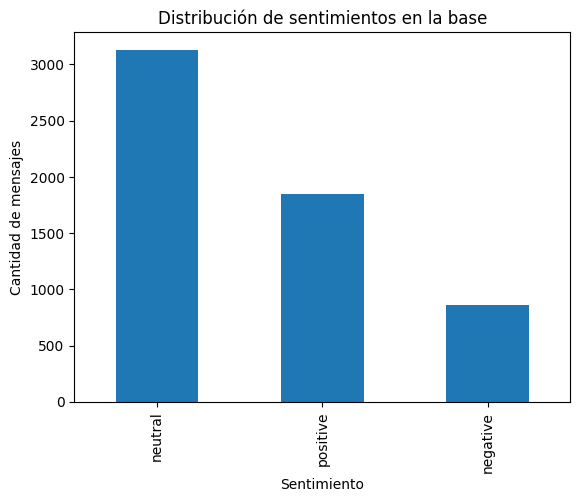

In [10]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title('Distribución de sentimientos en la base')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de mensajes')
plt.show()

5. Limpieza del texto

In [11]:
def clean_text(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [12]:
df['clean_text'] = df['Sentence'].apply(clean_text)

In [13]:
#revisamos la base con los textos limpios
df[['Sentence', 'clean_text']].head(10)

,Sentence,clean_text
0,The GeoSolutions technology will leverage Bene...,The GeoSolutions technology will leverage Bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...","$ESI on lows, down $1.50 to $2.50 BK a real po..."
2,"For the last quarter of 2010 , Componenta 's n...","For the last quarter of 2010 , Componenta 's n..."
3,According to the Finnish-Russian Chamber of Co...,According to the Finnish-Russian Chamber of Co...
4,The Swedish buyout firm has sold its remaining...,The Swedish buyout firm has sold its remaining...
5,$SPY wouldn't be surprised to see a green close,$SPY wouldn't be surprised to see a green close
6,Shell's $70 Billion BG Deal Meets Shareholder ...,Shell's $70 Billion BG Deal Meets Shareholder ...
7,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...
8,Kone 's net sales rose by some 14 % year-on-ye...,Kone 's net sales rose by some 14 % year-on-ye...
9,The Stockmann department store will have a tot...,The Stockmann department store will have a tot...


6. Eliminacion de emojis

Aunque los mensajes financieros no tienen tantos emojis es mejor asegurarnos de que no quede ninguno de estos elementos en los textos

In [14]:
def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)

    return emoji_pattern.sub(r'', text)

In [15]:
df['clean_text'] = df['clean_text'].apply(remove_emojis)

7. Eliminar stopwords

In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

print("Texto después de eliminar stopwords:")
print(df[['Sentence', 'clean_text']].head())

Texto después de eliminar stopwords:
                                            Sentence  \
0  The GeoSolutions technology will leverage Bene...   
1  $ESI on lows, down $1.50 to $2.50 BK a real po...   
2  For the last quarter of 2010 , Componenta 's n...   
3  According to the Finnish-Russian Chamber of Co...   
4  The Swedish buyout firm has sold its remaining...   

                                          clean_text  
0  GeoSolutions technology leverage Benefon 's GP...  
1         $ESI lows, $1.50 $2.50 BK real possibility  
2  quarter 2010 , Componenta 's net sales doubled...  
3  According Finnish-Russian Chamber Commerce , m...  
4  Swedish buyout firm sold remaining 22.4 percen...  


Se eliminaron las palabras vacías o stopwords para reducir términos frecuentes que no aportan informacion util y asi se concentra el analisis en palabras que den informacion mas importante.

Pero esta eliminación de stopwords puede afectar palabras que modifican el significado, por ejemplo negaciones como not. Por eso en la comparación con VADER es se debe tener mas cuidado con el preprocesamiento.

8. Análisis de sentimientos con TextBlob

- polarity: qué tan positivo o negativo es el texto.
- subjectivity: qué tanto corresponde a una opinión frente a un hecho.   

In [20]:
TextBlob('The company has excellent results').sentiment

Sentiment(polarity=1.0, subjectivity=1.0)

In [21]:
TextBlob('The company has terrible results').sentiment

Sentiment(polarity=-1.0, subjectivity=1.0)

El texto tiene una polaridad completamente positiva y un nivel máximo de subjetividad según la escala de TextBlob.

9. Crear funcion de polaridad

In [22]:
def get_polarity(text):
    analysis = TextBlob(text).sentiment
    return analysis.polarity

In [24]:
# se aplica
df['polarity'] = df['clean_text'].apply(get_polarity)
#se revisa
df[['clean_text', 'polarity']].head(10)

,clean_text,polarity
0,GeoSolutions technology leverage Benefon 's GP...,0.209091
1,"$ESI lows, $1.50 $2.50 BK real possibility",0.200000
2,"quarter 2010 , Componenta 's net sales doubled...",0.000000
3,"According Finnish-Russian Chamber Commerce , m...",0.062500
4,Swedish buyout firm sold remaining 22.4 percen...,-0.100000
5,$SPY wouldn't surprised green close,-0.050000
6,Shell's $70 Billion BG Deal Meets Shareholder ...,0.000000
7,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,0.000000
8,Kone 's net sales rose 14 % year-on-year month...,0.300000
9,Stockmann department store total floor space 8...,0.000000


10. guardar la subjetividad

In [25]:
def get_subjectivity(text):
    analysis = TextBlob(text).sentiment
    return analysis.subjectivity

In [27]:
df['subjectivity'] = df['clean_text'].apply(get_subjectivity)
#se revisa
df[['clean_text', 'polarity', 'subjectivity']].head(10)

,clean_text,polarity,subjectivity
0,GeoSolutions technology leverage Benefon 's GP...,0.209091,0.588636
1,"$ESI lows, $1.50 $2.50 BK real possibility",0.200000,0.300000
2,"quarter 2010 , Componenta 's net sales doubled...",0.000000,0.250000
3,"According Finnish-Russian Chamber Commerce , m...",0.062500,0.500000
4,Swedish buyout firm sold remaining 22.4 percen...,-0.100000,0.233333
5,$SPY wouldn't surprised green close,-0.050000,0.600000
6,Shell's $70 Billion BG Deal Meets Shareholder ...,0.000000,0.000000
7,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,0.000000,0.000000
8,Kone 's net sales rose 14 % year-on-year month...,0.300000,0.475000
9,Stockmann department store total floor space 8...,0.000000,0.750000


11. Convertir polaridad en categorias

In [28]:
def x_range(x):
    if x > 0:
        return 1
    elif x == 0:
        return 0
    else:
        return -1

In [29]:
#se aplica
df['result_textblob'] = df['polarity'].apply(x_range)

In [30]:
#para que se interprete mas facil
def sentiment_label(x):
    if x == 1:
        return 'positive'
    elif x == 0:
        return 'neutral'
    else:
        return 'negative'

In [31]:
df['TextBlob_Sentiment'] = df['result_textblob'].apply(sentiment_label)

12. Resultado de TextBlob

In [32]:
df['TextBlob_Sentiment'].value_counts()

,count
TextBlob_Sentiment,
neutral,3466
positive,1489
negative,887


In [33]:
df['TextBlob_Sentiment'].value_counts(normalize=True) * 100

,proportion
TextBlob_Sentiment,
neutral,59.328997
positive,25.487847
negative,15.183156


13. Grafico de TextBlob

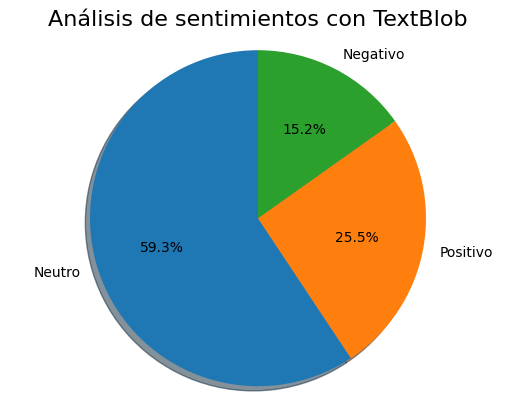

In [34]:
labels = 'Neutro', 'Positivo', 'Negativo'

plt.pie(
    df['result_textblob'].value_counts(),
    labels=labels,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)

plt.title('Análisis de sentimientos con TextBlob', fontsize=16)
plt.axis('equal')
plt.show()

14. Analizar la polaridad

In [35]:
df['polarity'].describe()

,polarity
count,5842.000000
mean,0.033093
std,0.184023
min,-1.000000
25%,0.000000
50%,0.000000
75%,0.025000
max,1.000000


In [36]:
df['subjectivity'].describe()

,subjectivity
count,5842.000000
mean,0.225621
std,0.283333
min,0.000000
25%,0.000000
50%,0.050000
75%,0.425938
max,1.000000


In [37]:
df.groupby('TextBlob_Sentiment')[['polarity', 'subjectivity']].mean()

,polarity,subjectivity
TextBlob_Sentiment,,
negative,-0.198755,0.399926
neutral,0.000000,0.064048
positive,0.248238,0.497887


Los mensajes positivos y negativos tienen una polaridad que corresponde a su clasificación.
Los neutrales tienen una polaridad de 0 y tambien muestran mucha menos subjetividad que los positivos y negativos

15. Comparar TextBlob con la etiqueta original

In [38]:
#primero transformamos la etiqueta original
df['Original_Sentiment'] = df['Sentiment']

In [39]:
pd.crosstab(
    df['Original_Sentiment'],
    df['TextBlob_Sentiment'],
    margins=True
)

TextBlob_Sentiment,negative,neutral,positive,All
Original_Sentiment,,,,
negative,226,513,121,860
neutral,473,1930,727,3130
positive,188,1023,641,1852
All,887,3466,1489,5842


Qué tanto coincide TextBlob con la clasificación original de los mensajes?

In [40]:
accuracy_textblob = (
    df['Original_Sentiment'] == df['TextBlob_Sentiment']
).mean()

accuracy_textblob

np.float64(0.47877439233139335)

16. Wordcloud

In [43]:
from wordcloud import WordCloud
text = ' '.join(df['clean_text'])

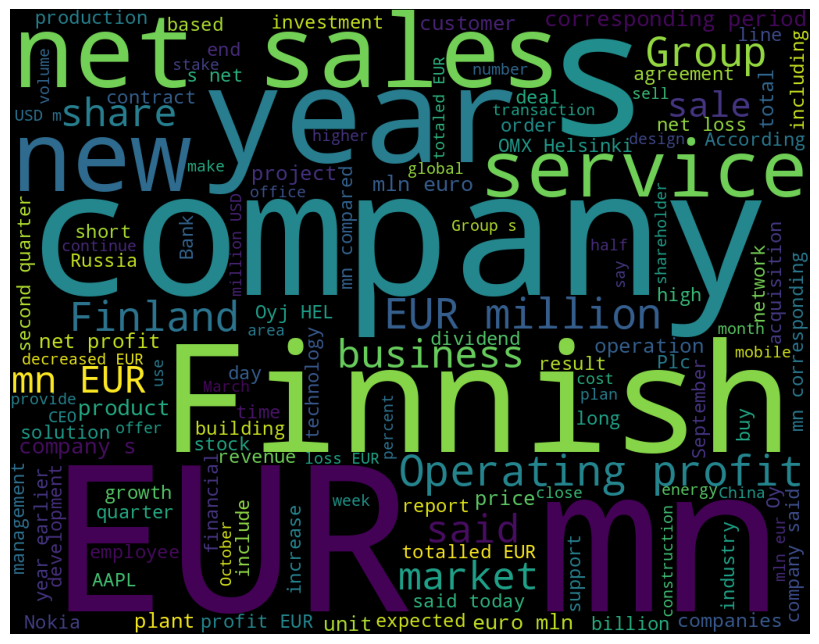

In [45]:
wordcloud = WordCloud(
    width=1024,
    height=800,
    min_font_size=14
).generate(text)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

17. Segundo metodo: VADER

usaremos Vader como otro metodo para explorar el análisis de sentimientos y compararlo con el que obtuvimos en el punto anterior

In [46]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [47]:
analyzer.polarity_scores("The company reported excellent financial results")

{'neg': 0.0, 'neu': 0.575, 'pos': 0.425, 'compound': 0.5719}

18. Funcion para Vader

In [48]:
def get_vader_score(text):
    return analyzer.polarity_scores(text)['compound']

In [49]:
df['vader_score'] = df['Sentence'].apply(get_vader_score)

Para VADER voy a usar el texto limpio pero no el texto al que le elimine todas las stopwords, porque VADER utiliza reglas lingüísticas y las negaciones pueden ser relevantes para determinar el sentimiento. Si elimino palabras como not, se puede modificar el significado original.

19. Clasificar VADER

In [50]:
def vader_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

In [51]:
df['VADER_Sentiment'] = df['vader_score'].apply(vader_sentiment)

20. Distribucion de VADER

In [52]:
df['VADER_Sentiment'].value_counts()

df['VADER_Sentiment'].value_counts(normalize=True) * 100

,proportion
VADER_Sentiment,
positive,46.302636
neutral,40.705238
negative,12.992126


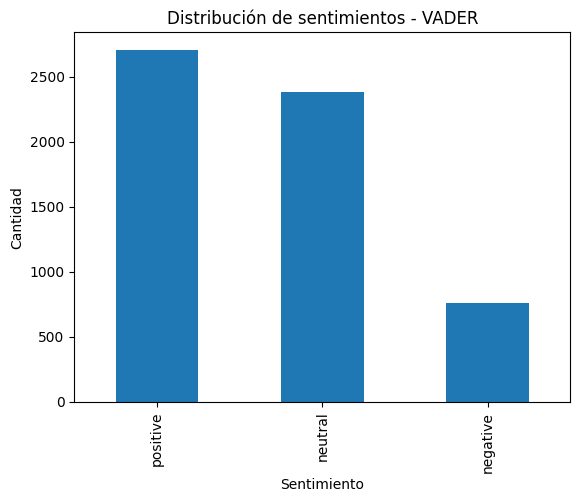

In [53]:
#realizamos el grafico
df['VADER_Sentiment'].value_counts().plot(kind='bar')

plt.title('Distribución de sentimientos - VADER')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.show()

Según VADER la mayoría de los mensajes son positivos y despues estan los neutrales. Los mensajes negativos representan la menor cantidad

21. Comparar TextBlob con VADER

In [54]:
pd.crosstab(
    df['TextBlob_Sentiment'],
    df['VADER_Sentiment']
)

VADER_Sentiment,negative,neutral,positive
TextBlob_Sentiment,,,
negative,228,367,292
neutral,421,1594,1451
positive,110,417,962


calculamos el porcentaje de coincidencia

In [55]:
agreement = (
    df['TextBlob_Sentiment'] == df['VADER_Sentiment']
).mean()

agreement

np.float64(0.4765491270112975)

22. Comparar ambos con la clasificacion original

In [56]:
comparison = pd.DataFrame({
    'Metodo': ['TextBlob', 'VADER'],
    'Coincidencia': [
        (df['TextBlob_Sentiment'] == df['Original_Sentiment']).mean(),
        (df['VADER_Sentiment'] == df['Original_Sentiment']).mean()
    ]
})

comparison

,Metodo,Coincidencia
0,TextBlob,0.478774
1,VADER,0.508559


TextBlob tiene una coincidencia de casi el 48% y VADER del 51%.

esto muestra que TextBlob y VADER no clasifican los mensajes de la misma manera. TextBlob identifica una mayor cantidad de mensajes como neutrales, y VADER clasifica más mensajes como positivos. La coincidencia entre ambos métodos es del 47%, lo que muestra que existen diferencias importantes en la forma en que cada método interpreta los mensajes financieros.

Vamos a analizar porque existen estas diferencias

23. Analisis por sentimiento original

In [58]:
pd.crosstab(
    df['Original_Sentiment'],
    df['TextBlob_Sentiment'],
    normalize='index'
) * 100

TextBlob_Sentiment,negative,neutral,positive
Original_Sentiment,,,
negative,26.279070,59.651163,14.069767
neutral,15.111821,61.661342,23.226837
positive,10.151188,55.237581,34.611231


In [59]:
pd.crosstab(
    df['Original_Sentiment'],
    df['VADER_Sentiment'],
    normalize='index'
) * 100

VADER_Sentiment,negative,neutral,positive
Original_Sentiment,,,
negative,33.488372,30.697674,35.813953
neutral,10.862620,49.137380,40.000000
positive,7.073434,31.101512,61.825054


En los mensajes originalmente clasificados como negativos, TextBlob clasificó el 26,28% como negativos, mientras que VADER clasificó el 33,49%. Ambos métodos  presentaron diferencias importantes al clasificar este grupo.

En los mensajes originalmente neutrales, TextBlob clasificó el 61,66% como neutrales,y VADER clasificó el 49,14%. Esto muestra que TextBlob mantuvo umas mensajes en la categoría neutral.

En los mensajes originalmente positivos si se evidencia una diferencia más marcada. TextBlob clasificó como positivos el 34,61%, y VADER clasificó como positivos el 61,83%. Esto indica que VADER identifica como positivo muchos mas mensajes que TextBlob.

24. Ejemplos donde existen estas diferencias

In [60]:
df[
    df['TextBlob_Sentiment'] != df['VADER_Sentiment']
][
    ['Sentence', 'Original_Sentiment',
     'TextBlob_Sentiment', 'polarity',
     'VADER_Sentiment', 'vader_score']
].head(20)

,Sentence,Original_Sentiment,TextBlob_Sentiment,polarity,VADER_Sentiment,vader_score
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,positive,0.200000,negative,-0.2023
2,"For the last quarter of 2010 , Componenta 's n...",positive,neutral,0.000000,positive,0.1531
3,According to the Finnish-Russian Chamber of Co...,neutral,positive,0.062500,neutral,0.0000
4,The Swedish buyout firm has sold its remaining...,neutral,negative,-0.100000,neutral,0.0000
6,Shell's $70 Billion BG Deal Meets Shareholder ...,negative,neutral,0.000000,negative,-0.2500
7,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,negative,neutral,0.000000,positive,0.2103
8,Kone 's net sales rose by some 14 % year-on-ye...,positive,positive,0.300000,neutral,0.0000
10,Circulation revenue has increased by 5 % in Fi...,positive,neutral,0.000000,positive,0.2732
11,$SAP Q1 disappoints as #software licenses down...,negative,positive,0.022222,negative,-0.4019
12,The subdivision made sales revenues last year ...,positive,neutral,0.000000,positive,0.4404


Caso 1 de ejemplo donde los metodos difieren

1. ($ESI on lows, down $1.50 to $2.50 BK...)

Original: Negativo
TextBlob: Positivo, polaridad 0.20
VADER: Negativo, -0.2023

El mensaje contiene expresiones financieras como "on lows" y "down".

En este caso, TextBlob lo clasifica como positivo y VADER lo clasifica como negativo. Esto puede deberse a que VADER identifica expresiones como "down" dentro del contexto del mensaje, mientras que TextBlob le da una polaridad positiva al texto.

y otro caso es la fila 2:
For the last quarter of 2010, Componenta's...

Original: Positivo
TextBlob: Neutral, 0.0
VADER: Positivo, 0.1531

En este mensaje TextBlob no encuentra suficientes palabras con carga positiva y lo clasifica como neutral, mientras que VADER le da una puntuación positiva.

25. Conclusion

El análisis de los 5.842 mensajes financieros nos permitió ver que TextBlob y VADER pueden dar resultados diferentes al analizar un mismo texto. En la clasificación original de los datos la mayoría de los mensajes son neutrales, esto tiene sentido porque muchos de ellos simplemente presentan información sobre empresas, ventas, resultados o mercados.

Con TextBlob los mensajes positivos tuvieron una polaridad promedio de 0,248, los negativos de -0,199 y los neutrales de 0. Ademas los mensajes neutrales tuvieron una subjetividad promedio de 0,064, mientras que los positivos tuvieron 0,498 y los negativos 0,400. Esto muestra que los mensajes neutrales dan mas informacion y no estan tan basados en opiniones.

Al comparar TextBlob y VADER los dos métodos coincidieron en el 47% de los mensajes. Esto significa que en muchos casos los métodos clasificaron de manera diferente un mismo texto. Al compararlos con la clasificación original de la base, TextBlob tuvo una coincidencia del 47,88% y VADER del 50,86%.

También se encontraron diferencias entre las categorías. Por ejemplo en los mensajes que originalmente eran positivos, VADER clasificó como positivos el 61,83%, y TextBlob clasificó como positivos el 34,61%. En los mensajes neutrales, TextBlob clasificó como neutrales el 61,66%, mientras que VADER clasificó como neutrales el 49,14%.

Al revisar algunos mensajes específicos vimos que los dos métodos pueden interpretar de manera diferente palabras y expresiones relacionadas con las finanzas. Por ejemplo palabras como down, growth, loss, sales o profit pueden tener un significado particular dependiendo del contexto en el que aparecen.

En conclusión TextBlob y VADER son útiles para identificar patrones generales de sentimiento, pero sus resultados no siempre son iguales. Por eso al analizar mensajes financieros es importante tener en cuenta el método utilizado y también el contexto del mensaje.